# Neural Networks with SKlearn

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd
import random

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [26]:
digits = pl.read_csv("./data/digits.csv")
labels = digits["label"].to_numpy()
digits = np.array(digits.drop(["label"]).cast(pl.Float64))

In [27]:
digits.shape, labels.shape

((42000, 784), (42000,))

In [28]:
digits.dtype, labels.dtype

(dtype('float64'), dtype('int64'))

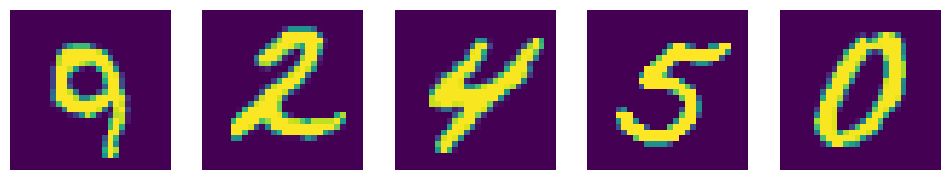

In [29]:
plt.figure(figsize=(12,4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(random.choice(digits).reshape(28,28))
    plt.axis("off")

In [30]:
train_size = 0.7
scaler = MinMaxScaler()
digits = scaler.fit_transform(digits)

X_train, X_test, y_train, y_test = train_test_split(digits, labels, train_size=train_size)

Sklearn contains a MLP Classifier (MultiLayer Perceptron). By default it will be initialised with a single hidden layer of size 100.

In [31]:
model = MLPClassifier().fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Using MLPClassifier with the default parameter values gives an accuracy of {accuracy_score(y_pred, y_test)}")

Using MLPClassifier with the default parameter values gives an accuracy of 0.9708753273549718


In [32]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1219
           1       0.98      0.98      0.98      1387
           2       0.98      0.97      0.97      1263
           3       0.96      0.97      0.96      1328
           4       0.96      0.98      0.97      1220
           5       0.95      0.97      0.96      1121
           6       0.98      0.97      0.98      1231
           7       0.98      0.96      0.97      1302
           8       0.97      0.96      0.96      1231
           9       0.96      0.97      0.96      1299

    accuracy                           0.97     12601
   macro avg       0.97      0.97      0.97     12601
weighted avg       0.97      0.97      0.97     12601



Below we use randomized search to find the best hyperparameter settings for the multilayer perceptron.

In [33]:
parameters = {'hidden_layer_sizes':[50, 100, 200],
              'alpha': [0.001, 0.01, 0.1], 
              'max_iter': [200, 500, 800], 
              'learning_rate_init':[0.0001, 0.001, 0.01, 0.1]}

model = MLPClassifier()
clf = RandomizedSearchCV(estimator=model, param_distributions=parameters, cv=5)
clf.fit(X_train[:3000], y_train[:3000]) # reduce the train set size to shorten the training time

print("The best parameter values found are:\n")
print(clf.best_params_)

# store the best model found in "bestmodel"
bestmodel = clf.best_estimator_

p:\02_Poetry\Cache\virtualenvs\ibm-ml-sD2suF2h-py3.12\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
p:\02_Poetry\Cache\virtualenvs\ibm-ml-sD2suF2h-py3.12\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
p:\02_Poetry\Cache\virtualenvs\ibm-ml-sD2suF2h-py3.12\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
p:\02_Poetry\Cache\virtualenvs\ibm-ml-sD2suF2h-py3.12\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimiza

The best parameter values found are:

{'max_iter': 800, 'learning_rate_init': 0.01, 'hidden_layer_sizes': 200, 'alpha': 0.1}


This results in a best model that has many iterations (epochs) for training (better performance when trained longer). A learning rate that is slightly lower than default. A hidden layer size of 200, slightly higher than default. And a relatively high L2 regularization term (alpha).

Below some classified samples from the test set are shown

The accuracy score of the best model is 0.9334179826997857



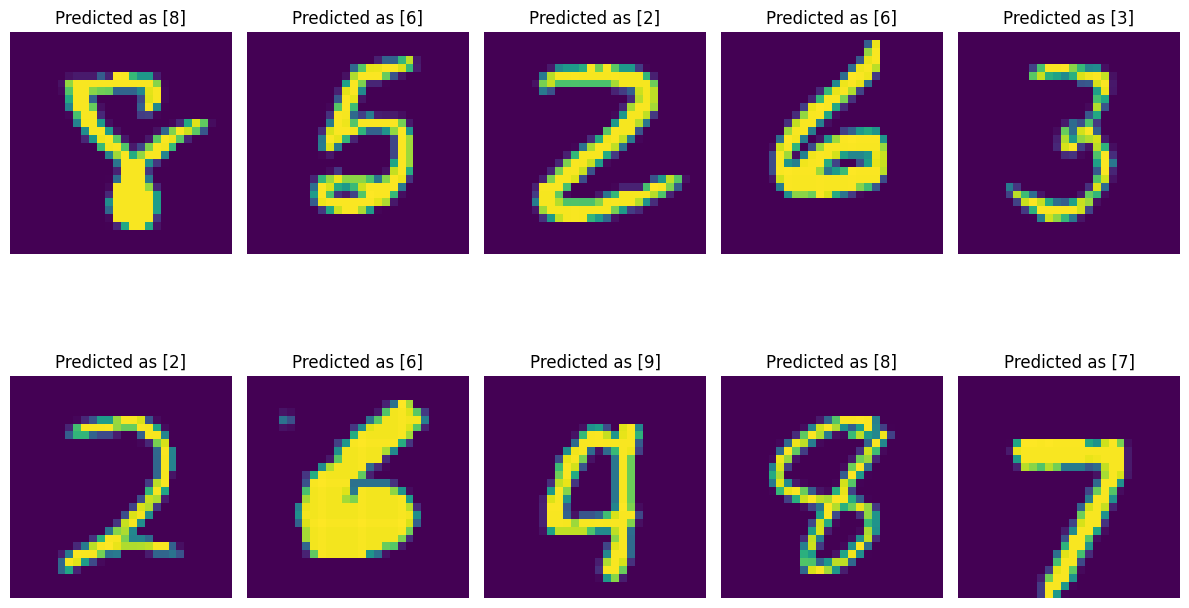

In [34]:
y_pred = bestmodel.predict(X_test)
print(f"The accuracy score of the best model is {accuracy_score(y_test, y_pred)}\n")

plt.figure(figsize=(12,8))
for i in range(10):
    plt.subplot(2, 5, i+1)
    sample = random.choice(X_test)
    plt.imshow(sample.reshape(28,28))
    pred = bestmodel.predict(sample.reshape(1,-1))
    plt.title(f"Predicted as {pred}")
    plt.axis("off")

plt.tight_layout()